# **데이터 전처리**

* 예제데이터
    * 타이타닉
    * 뉴욕 공기오염도
    * 카시트 판매량

## **0. 환경준비**

### (1) Import

In [75]:
# 기본 라이브러리 가져오기
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

### (2) Data Loading

* 타이타닉 데이터

|	변수명	|	설명	|	구분	|
|----|----|----|
|	Survived 	|	 생존여부(범주 : 0,1)	|	Target	|
|	Pclass 	|	객실등급(범주 :1,2,3)	|	feature	|
|	Sex 	|	 성별(범주 : male, female)	|	feature|
|	Age 	|	 나이	|	feature	|
|	SibSp 	|	 배우자 혹은 형제자매 수	|	feature	|
|	Parch 	|	 부모 혹은 자녀 수	|	feature	|
|	Fare 	|	 운임(단위 : 달러)	|	feature	|
|	Cabin 	|	 객실번호	|	feature	|
|	Embarked 	|	 승선지(범주 : S(southampton), Q(queenstown), C(cherbourg)	|	feature	|


In [76]:
# titanic
path = 'https://raw.githubusercontent.com/DA4BAM/dataset/master/titanic.0.csv'
titanic = pd.read_csv(path, usecols = ['Survived','Pclass','Sex','Age','SibSp','Parch','Fare','Cabin','Embarked'])
titanic.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,0,3,male,22.0,1,0,7.2500,NaN,S
1,1,1,female,38.0,1,0,71.2833,C85,C
2,1,3,female,26.0,0,0,7.9250,NaN,S
3,1,1,female,35.0,1,0,53.1000,C123,S
4,0,3,male,35.0,0,0,8.0500,NaN,S


* 뉴욕 공기오염도 데이터

|	변수명	|	설명	|	구분	|
|----|----|----|
|	Ozone 	|	 오존농도	|	Target	|
|	Solar.R 	|	태양복사열	|	feature	|
|	Temp 	|	 온도(화씨)	|	feature|
|	Wind	|	 바람세기	|	feature	|
|	Day 	|	 관측일	|	feature	|

In [77]:
# airquality
path = 'https://raw.githubusercontent.com/DA4BAM/dataset/master/air2.csv'
air = pd.read_csv(path)
air.head()

,Ozone,Solar.R,Wind,Temp,Date
0,41,190.0,7.4,67,1973-05-01
1,36,118.0,8.0,72,1973-05-02
2,12,149.0,12.6,74,1973-05-03
3,18,313.0,11.5,62,1973-05-04
4,19,NaN,14.3,56,1973-05-05


* 카시트 판매량 데이터

|	변수명	|	설명	|	구분	|
|----|----|----|
|	Sales 	|	 각 지역 판매량(단위 : 1000개)	|	Target	|
|	CompPrice 	|	지역별 경쟁사 판매가격(달러)	|	feature	|
|	Advertising 	|	 각 지역, 회사의 광고 예산(단위 : 1000달러)	|	feature|
|	Income 	|	 지역 주민 평균소득(단위 : 1000달러)	|	feature	|
|	Population 	|	 지역 인구수(단위 : 1000명)	|	feature	|
|	Price 	|	 자사 지역별 판매가격(달러)	|	feature	|
|	ShelveLoc 	|	 진열상태(범주 : Bad, Medium, Good)	|	feature	|
|	Age 	|	 지역 인구의 평균 연령	|	feature	|
|	US 	|	 매장이 미국에 있는지 여부(범주 : Yes, No)	|	feature	|
|	Urban 	|	 매장이 도시에 있는지 여부(범주 : Yes, No)	|	feature	|
|	Education 	|	 평균학력수준(범주 : 11~17)	|	feature	|


In [78]:
path = 'https://raw.githubusercontent.com/DA4BAM/dataset/master/Carseats_NA.csv'
carseat = pd.read_csv(path)
carseat.head()

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,9.50,138.0,73.0,11,276,120,Bad,42,17,Yes,Yes
1,11.22,111.0,48.0,16,260,83,Good,65,10,Yes,Yes
2,10.06,113.0,35.0,10,269,80,Medium,59,12,Yes,Yes
3,7.40,117.0,100.0,4,466,97,Medium,55,14,Yes,Yes
4,4.15,141.0,64.0,3,340,128,Bad,38,13,Yes,No


## **1. 데이터 전처리**

### (1) 데이터 분할

#### ① x, y 분할하기

In [79]:
target = 'Survived'
x = titanic.drop(target, axis = 1)
y = titanic.loc[:, target]

In [80]:
x.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,3,male,22.0,1,0,7.2500,NaN,S
1,1,female,38.0,1,0,71.2833,C85,C
2,3,female,26.0,0,0,7.9250,NaN,S
3,1,female,35.0,1,0,53.1000,C123,S
4,3,male,35.0,0,0,8.0500,NaN,S


In [81]:
y.head()

,Survived
0,0
1,1
2,1
3,1
4,0


#### ② train : validation 분할하기
* 분할된 데이터셋 용도
    * train : 모델링(학습) 용
    * val : 모델 검증 용
* train_test_split : https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html
* 주요 옵션
    * test_size 혹은 train_size : 소수 - 비율로 분할, 자연수 - 건수로 분할
    * shuffle : True(기본값) 랜덤하게 섞어서 분할, False - 데이터셋 인덱스 순서대로 분할(주로, 시계열 데이터를 시간순으로 분할할 때 사용)
    * random_state : shuffle이 True일 때, 지정한 숫자가 같으면 동일한 규칙으로 섞음(우리는 규칙을 알 수 없음)

In [82]:
from sklearn.model_selection import train_test_split

In [83]:
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size = .3)

In [84]:
x_train.shape, x_val.shape

((623, 8), (268, 8))

#### 📝복습문제

* 뉴욕 공기오염도 데이터를 분할하시오.
    * 뉴욕 공기오염도 데이터는 시계열 데이터입니다.
    * target : Ozone
    * val 건수 : 60건
    * 분할1 : x2, y2
    * 분할2 : x2_train, x2_val, y2_train, y2_val

In [85]:
target = 'Ozone'
x2 = air.drop(target, axis = 1)
y2 = air.loc[:, target]

# val건수 60이라서 전체에 대한 60의 값을 비율을 val_size로 설정
val_size = 60 / len(x2)
x2_train, x2_val, y2_train, y2_val = train_test_split(x2, y2, test_size = val_size)

* 카시트 판매량 데이터를 분할하시오.
    * target : Sales
    * train : val = 8 : 2
    * 분할1 : x3, y3
    * 분할2 : x3_train, x3_val, y3_train, y3_val

In [86]:
target = 'Sales'
x3 = carseat.drop(target, axis = 1)
y3 = carseat.loc[:, target]

In [87]:
x3_train, x3_val, y3_train, y3_val = train_test_split(x3, y3, test_size = .2)

### (2) NaN 조치

#### ① 결측치 확인

In [88]:
x.isna().sum()
# x.isnull().sum()

,0
Pclass,0
Sex,0
Age,177
SibSp,0
Parch,0
Fare,0
Cabin,687
Embarked,2


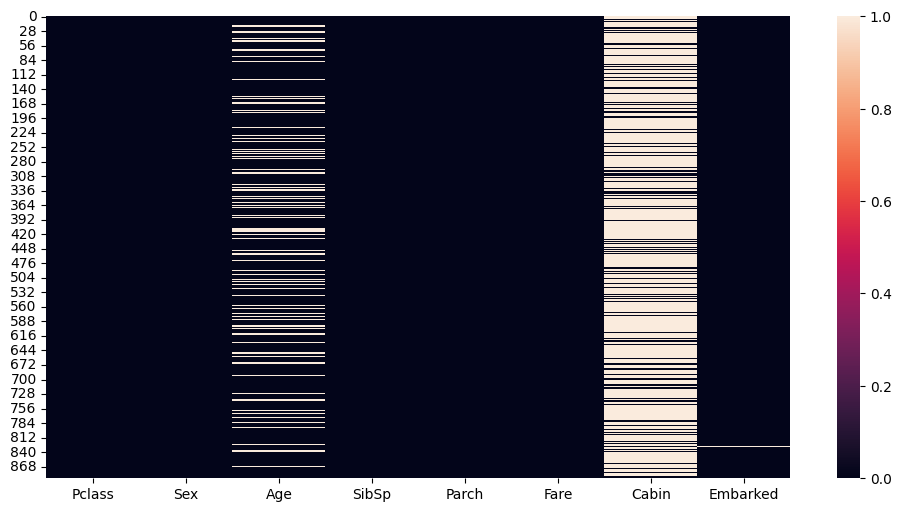

In [89]:
plt.figure(figsize = (12,6))
sns.heatmap(x.isna())
plt.show()

* 📝복습문제
    * 뉴욕공기오염도 데이터에 대해서 NaN을 찾아 봅시다.

In [90]:
x2.isna().sum()

,0
Solar.R,7
Wind,0
Temp,0
Date,0


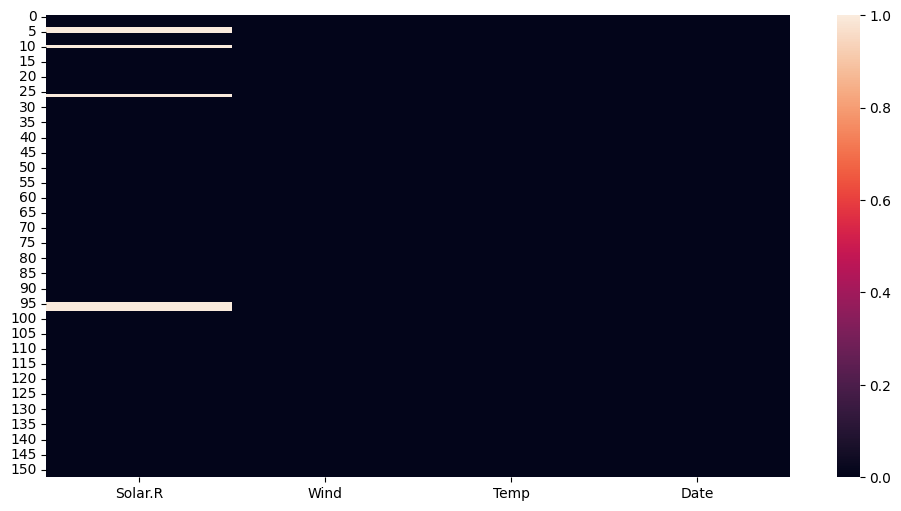

In [91]:
plt.figure(figsize = (12,6))
sns.heatmap(x2.isna())
plt.show()


* 📝복습문제
    * 카시트 판매량 데이터에 대해서 NaN을 찾아 봅시다.

In [92]:
x3.isna().sum()

,0
CompPrice,17
Income,19
Advertising,0
Population,0
Price,0
ShelveLoc,0
Age,0
Education,0
Urban,0
US,0


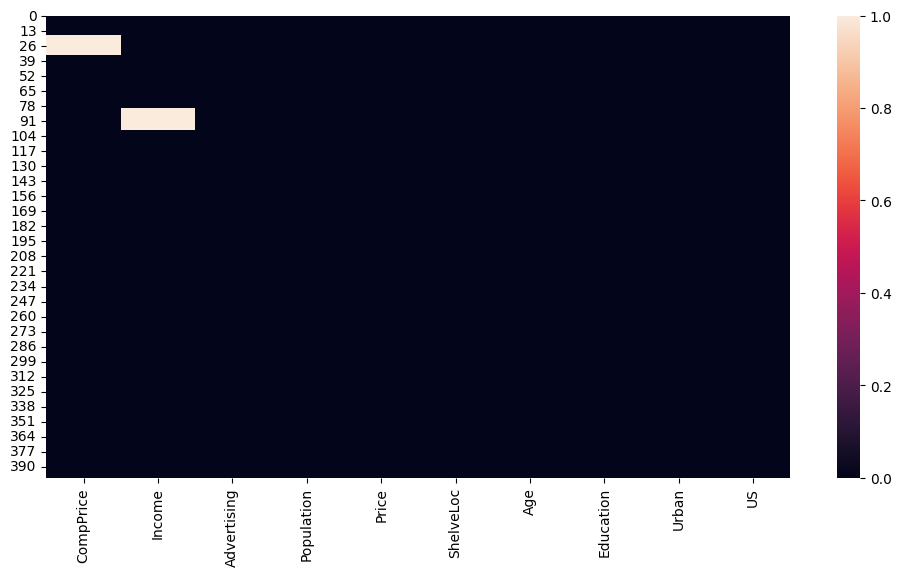

In [93]:
plt.figure(figsize = (12,6))
sns.heatmap(x3.isna())
plt.show()

#### ② 결측치 제거

In [94]:
# 데이터프레임 x_train을 temp로 복사
temp = x_train.copy()

In [95]:
temp.shape

(623, 8)

* 행 제거
    * 행을 제거할 때
        * NaN이 적고,
        * 운영에서 NaN이 발생하지 않거나, 무시할 수 있을 때.
    * dropna : https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.dropna.html

* 전체에서 NaN이 하나라도 있는 모든행 제거

In [96]:
temp.dropna(axis = 0, inplace = True)
temp.isna().sum()

,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Cabin,0
Embarked,0


In [97]:
temp.shape

(128, 8)

* 특정 열의 NaN이 포함된 행 제거
    * subset = [칼럼이름] (반드시 리스트로 입력되어야 합니다.)

In [98]:
temp = x_train.copy()
temp.shape

(623, 8)

In [99]:
temp.isna().sum()

,0
Pclass,0
Sex,0
Age,132
SibSp,0
Parch,0
Fare,0
Cabin,478
Embarked,2


In [100]:
# Age에서 NaN이 있는 행 제거
temp.dropna(axis = 0, subset = ['Age'], inplace = True)
temp.shape

(491, 8)

In [101]:
# 다시 복사해서, 이번엔, Age와 Embarked 중에서 NaN이 있는 행을 제거합시다.
temp = x_train.copy()
temp.dropna(axis = 0, subset = ['Age', 'Embarked'], inplace = True)
temp.shape

(489, 8)

In [102]:
temp.isna().sum()

,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Cabin,361
Embarked,0


* 열 제거
    * 열을 제거할 때
        * NaN이 많거나, 변수(열)가 중요하지 않을 때
    * 제거 방법
        * dropna : NaN이 있는 열 모두 제거
        * drop : 특정 행 제거

In [103]:
temp = x_train.copy()
temp.isna().sum()

,0
Pclass,0
Sex,0
Age,132
SibSp,0
Parch,0
Fare,0
Cabin,478
Embarked,2


* dropna로 NaN이 포함된 모든 열 삭제

In [104]:
temp.dropna(axis = 1, inplace = True)
temp.isna().sum()

,0
Pclass,0
Sex,0
SibSp,0
Parch,0
Fare,0


* drop으로 특정 열을 삭제합시다.

In [105]:
temp = x_train.copy()
temp.drop('Cabin', axis = 1, inplace = True)
temp.isna().sum()

,0
Pclass,0
Sex,0
Age,132
SibSp,0
Parch,0
Fare,0
Embarked,2


* 📝복습문제
    * 뉴욕공기오염도 데이터 x2_train을 temp2로 복사해 놓고
    * NaN이 있는 전체 행을 제거합시다.

In [106]:
temp2 = x2_train.copy()
temp2.dropna(axis = 0, inplace = True)
temp2.isna().sum()

,0
Solar.R,0
Wind,0
Temp,0
Date,0


* 📝복습문제
    * 카시트 데이터를 x3_train을 temp2로 복사해 놓고
        * Income 변수의 NaN 행을 제거합시다.
        * CompPrice 열을 제거.

In [107]:
# Income 변수의 NaN 행을 제거합시다.
temp3 = x3_train.copy()

temp3.dropna(axis = 0, subset = ['Income'], inplace = True)
temp3.isna().sum()


,0
CompPrice,13
Income,0
Advertising,0
Population,0
Price,0
ShelveLoc,0
Age,0
Education,0
Urban,0
US,0


In [108]:
# CompPrice 열을 제거.
temp3.drop('CompPrice', axis = 1, inplace = True)
temp3.isna().sum()

,0
Income,0
Advertising,0
Population,0
Price,0
ShelveLoc,0
Age,0
Education,0
Urban,0
US,0


#### ③ 결측치 채우기

* fillna와 SimpleImputer를 배웁니다. 기능이 겹치는 부분이 있습니다.
* 추천하는 용도는 다음과 같습니다.
    * 시계열 데이터 : .fillna, .interpolate
    * 비시계열 데이터 : SimpleImputer

#####.fillna
* 단일값, 0으로 채우기 : .fillna(0)
* 이전 값으로 채우기 : .fillna(method = 'ffill')
* 이후 값으로 채우기 .fillna(method = 'bfill')
* https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.fillna.html

In [109]:
temp = air.copy()
temp.head()

,Ozone,Solar.R,Wind,Temp,Date
0,41,190.0,7.4,67,1973-05-01
1,36,118.0,8.0,72,1973-05-02
2,12,149.0,12.6,74,1973-05-03
3,18,313.0,11.5,62,1973-05-04
4,19,NaN,14.3,56,1973-05-05


* 단일값으로 채우기

In [110]:
# 단일값으로 채우는 것처럼 조회
temp.fillna(0).head(7)

,Ozone,Solar.R,Wind,Temp,Date
0,41,190.0,7.4,67,1973-05-01
1,36,118.0,8.0,72,1973-05-02
2,12,149.0,12.6,74,1973-05-03
3,18,313.0,11.5,62,1973-05-04
4,19,0.0,14.3,56,1973-05-05
5,28,0.0,14.9,66,1973-05-06
6,23,299.0,8.6,65,1973-05-07


In [111]:
temp.head(7)

,Ozone,Solar.R,Wind,Temp,Date
0,41,190.0,7.4,67,1973-05-01
1,36,118.0,8.0,72,1973-05-02
2,12,149.0,12.6,74,1973-05-03
3,18,313.0,11.5,62,1973-05-04
4,19,NaN,14.3,56,1973-05-05
5,28,NaN,14.9,66,1973-05-06
6,23,299.0,8.6,65,1973-05-07


In [112]:
# 단일값으로 진짜 채우기 : inplace = True
temp.fillna(0, inplace = True)
temp.head(7)

,Ozone,Solar.R,Wind,Temp,Date
0,41,190.0,7.4,67,1973-05-01
1,36,118.0,8.0,72,1973-05-02
2,12,149.0,12.6,74,1973-05-03
3,18,313.0,11.5,62,1973-05-04
4,19,0.0,14.3,56,1973-05-05
5,28,0.0,14.9,66,1973-05-06
6,23,299.0,8.6,65,1973-05-07


* 이전값, 이후값으로 채우기(시계열 데이터에만 가능!)

In [113]:
temp = air.copy()

In [114]:
# 이전 값으로 채우기
temp.fillna(method = 'ffill').head(7)

/tmp/ipython-input-2566494860.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  temp.fillna(method = 'ffill').head(7)


,Ozone,Solar.R,Wind,Temp,Date
0,41,190.0,7.4,67,1973-05-01
1,36,118.0,8.0,72,1973-05-02
2,12,149.0,12.6,74,1973-05-03
3,18,313.0,11.5,62,1973-05-04
4,19,313.0,14.3,56,1973-05-05
5,28,313.0,14.9,66,1973-05-06
6,23,299.0,8.6,65,1973-05-07


##### .interpolate(method = 'linear')
* 전,후 값의 사이값으로 채우기(시계열 데이터에만 가능!)
* https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.interpolate.html

In [115]:
temp.interpolate(method = 'linear').head(7)

/tmp/ipython-input-1895253540.py:1: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  temp.interpolate(method = 'linear').head(7)


,Ozone,Solar.R,Wind,Temp,Date
0,41,190.000000,7.4,67,1973-05-01
1,36,118.000000,8.0,72,1973-05-02
2,12,149.000000,12.6,74,1973-05-03
3,18,313.000000,11.5,62,1973-05-04
4,19,308.333333,14.3,56,1973-05-05
5,28,303.666667,14.9,66,1973-05-06
6,23,299.000000,8.6,65,1973-05-07


* 📝복습문제
    * titanic 데이터 x_train를 temp1로 복사해 놓고
        * Age에 대해서 평균값으로 채우시오.
        * Embarked에 대해서 최빈값으로 채우시오.
            * 최빈값 : series.mode()

In [116]:
temp1 = x_train.copy()
temp1.isna().sum()

,0
Pclass,0
Sex,0
Age,132
SibSp,0
Parch,0
Fare,0
Cabin,478
Embarked,2


In [117]:
Age_mean = temp1['Age'].mean()
temp1['Age'].fillna(Age_mean, inplace=True)

Embarked_mode = temp1['Embarked'].mode()[0]
temp1['Embarked'].fillna(Embarked_mode, inplace=True)

temp1[['Age', 'Embarked']].isna().sum()

/tmp/ipython-input-1083856818.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  temp1['Age'].fillna(Age_mean, inplace=True)
/tmp/ipython-input-1083856818.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using '

,0
Age,0
Embarked,0


* 📝복습문제
    * 공기오염도 x2_train을 temp2에 복사해 놓고
    * 이후값(bfill)으로 채우시오.

In [118]:
temp2 = x2_train.copy()
temp2.isna().sum()

,0
Solar.R,6
Wind,0
Temp,0
Date,0


In [119]:
temp2.fillna(method = 'bfill', inplace = True)
temp2.isna().sum()

/tmp/ipython-input-4219205221.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  temp2.fillna(method = 'bfill', inplace = True)


,0
Solar.R,0
Wind,0
Temp,0
Date,0


##### SimpleImputer
* https://scikit-learn.org/stable/modules/generated/sklearn.impute.SimpleImputer.html
* 특정값으로 채우기
    * 최빈값
    * 중앙값
    * 평균값
    * 상수

* Age에 대해 평균값으로 채워 봅시다.

In [120]:
from sklearn.impute import SimpleImputer

In [121]:
temp = x_train.copy()
temp.isna().sum()

,0
Pclass,0
Sex,0
Age,132
SibSp,0
Parch,0
Fare,0
Cabin,478
Embarked,2


In [122]:
# 선언
imputer1 = SimpleImputer(strategy = 'mean')

# 만들고 적용 : .fit_transform (.fit + .tranform)
# 반드시 입력은 2차원이어야 함.
temp[['Age']] = imputer1.fit_transform(temp[['Age']])

temp.isna().sum()

,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Cabin,478
Embarked,2


* Embarked는 최빈값(strategy = 'most_frequent')로 채워 봅시다.

In [123]:
# 선언
imputer2 = SimpleImputer(strategy = 'most_frequent')

# 만들고 적용하기
x[['Embarked']] = imputer2.fit_transform(x[['Embarked']])
x.isna().sum()

,0
Pclass,0
Sex,0
Age,177
SibSp,0
Parch,0
Fare,0
Cabin,687
Embarked,0


* 📝복습문제
    * 카시트 데이터 x3_train을 temp3로 복사해 놓고
    * NaN이 존재하는 변수들에 대해서 모두 평균으로 채우시오.

In [124]:
temp3 = x3_train.copy()
imputer = SimpleImputer(strategy='mean')

num_cols = temp3.select_dtypes(include=['int64', 'float64']).columns

temp3[num_cols] = imputer.fit_transform(temp3[num_cols])

In [125]:
temp3.isna().sum()

,0
CompPrice,0
Income,0
Advertising,0
Population,0
Price,0
ShelveLoc,0
Age,0
Education,0
Urban,0
US,0


### (3) 가변수화

* 모델링을 위해서 모든 데이터 값은 숫자 여야 합니다.
* 숫자 형식이 아니라 의미상 숫자
    * 타이타닉 데이터의 pclass(객실등급)가 1,2,3 입니다. 이는 숫자 형식이지만 숫자의 의미는 아닙니다. (3등급 객실의 3이 1등급 객실의 1에 3배의 의미는 아니라는 말입니다.)
* 그러므로 모든 범주형 변수는 모두 (이미 0,1로 되어 있는 변수를 빼고) 가변수화를 수행해야 합니다.

* 가변수화 방법
    * 아래 설명하는 절차는 교과서적인 방법입니다.
    * 좀 간단한 방법은 다음 시간에 다루겠습니다.

In [126]:
x_train.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
57,3,male,28.5,0,0,7.2292,NaN,C
588,3,male,22.0,0,0,8.0500,NaN,S
186,3,female,NaN,1,0,15.5000,NaN,Q
500,3,male,17.0,0,0,8.6625,NaN,S
232,2,male,59.0,0,0,13.5000,NaN,S


#### ① 가변수화 준비
* 대상 변수에 대해 범주 목록 만들기
    * 데이터 이해단계에서, 데이터에 대한 정보 사전을 정리할 때 범주형 변수의 **범주 목록을 정리**해야 합니다.

In [127]:
cat_cols = { 'Pclass':[1,2,3]
            , 'Sex':['male','female']
            , 'Embarked':['S','Q','C']}

* 변수를 Categorical로 변환하기

In [128]:
# 데이터프레임의 변수 정보 확인
x_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 623 entries, 57 to 77
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    623 non-null    int64  
 1   Sex       623 non-null    object 
 2   Age       491 non-null    float64
 3   SibSp     623 non-null    int64  
 4   Parch     623 non-null    int64  
 5   Fare      623 non-null    float64
 6   Cabin     145 non-null    object 
 7   Embarked  621 non-null    object 
dtypes: float64(2), int64(3), object(3)
memory usage: 43.8+ KB


In [129]:
# 딕셔너리.items() : 키와 값 쌍으로 출력
cat_cols.items()

dict_items([('Pclass', [1, 2, 3]), ('Sex', ['male', 'female']), ('Embarked', ['S', 'Q', 'C'])])

In [130]:
for v, cat in cat_cols.items() :
    x_train[v] = pd.Categorical(x_train[v], categories = cat)

In [131]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 623 entries, 57 to 77
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   Pclass    623 non-null    category
 1   Sex       623 non-null    category
 2   Age       491 non-null    float64 
 3   SibSp     623 non-null    int64   
 4   Parch     623 non-null    int64   
 5   Fare      623 non-null    float64 
 6   Cabin     145 non-null    object  
 7   Embarked  621 non-null    category
dtypes: category(3), float64(2), int64(2), object(1)
memory usage: 31.4+ KB


#### ② 가변수화 적용

In [132]:
cat_cols.keys()

dict_keys(['Pclass', 'Sex', 'Embarked'])

In [133]:
# 가변수화 수행
x_train = pd.get_dummies(x_train, columns = cat_cols.keys(), drop_first = True)
x_train.head()

,Age,SibSp,Parch,Fare,Cabin,Pclass_2,Pclass_3,Sex_female,Embarked_Q,Embarked_C
57,28.5,0,0,7.2292,NaN,False,True,False,False,True
588,22.0,0,0,8.0500,NaN,False,True,False,False,False
186,NaN,1,0,15.5000,NaN,False,True,True,True,False
500,17.0,0,0,8.6625,NaN,False,True,False,False,False
232,59.0,0,0,13.5000,NaN,True,False,False,False,False


* drop_first = True : 가변수화 시, 첫번째 범주 열 삭제. ➜ 하나를 빼도 모든 범주 표현 가능.
    * 삭제해야 하는 알고리즘 : Linear Regression, Logisitic Regression
    * 삭제하지 않아도 되는 알고리즘 : Tree 기반 알고리즘들, 딥러닝 등

#### 📝복습문제
* carseat : x3_train에 대해서 가변수화를 수행하시오.

In [134]:
x3_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 320 entries, 56 to 246
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   CompPrice    307 non-null    float64
 1   Income       303 non-null    float64
 2   Advertising  320 non-null    int64  
 3   Population   320 non-null    int64  
 4   Price        320 non-null    int64  
 5   ShelveLoc    320 non-null    object 
 6   Age          320 non-null    int64  
 7   Education    320 non-null    int64  
 8   Urban        320 non-null    object 
 9   US           320 non-null    object 
dtypes: float64(2), int64(5), object(3)
memory usage: 27.5+ KB


In [135]:
cat_cols2 = {'ShelveLoc':['Bad','Medium','Good']
            , 'Urban':['Yes','No']
            , 'US':['Yes','No']}
cat_cols2.items()

dict_items([('ShelveLoc', ['Bad', 'Medium', 'Good']), ('Urban', ['Yes', 'No']), ('US', ['Yes', 'No'])])

In [136]:
for v , cat in cat_cols2.items() :
    x3_train[v] = pd.Categorical(x3_train[v], categories = cat)

In [138]:
dumm_cols = ['ShelveLoc', 'Urban', 'US']

x3_train = pd.get_dummies(x3_train, columns=dumm_cols, drop_first=True)

In [139]:
cat_cols2.keys()

dict_keys(['ShelveLoc', 'Urban', 'US'])

In [141]:
x3_train.head()

,CompPrice,Income,Advertising,Population,Price,Age,Education,ShelveLoc_Medium,ShelveLoc_Good,Urban_No,US_No
56,133.0,82.0,0,54,84,50,17,True,False,False,True
16,118.0,32.0,0,284,110,63,13,False,True,False,True
176,138.0,107.0,9,480,154,47,11,True,False,True,False
244,130.0,30.0,0,391,100,26,18,True,False,False,True
71,148.0,51.0,16,148,150,58,17,True,False,True,False


### (4) 스케일링

In [142]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

* 정규화(Normalization, MinMax 방식)
    * 모든 값을 0 ~ 1 로.

In [143]:
# 선언하기
scaler1 = MinMaxScaler()

# 만들고 적용 .fit_transform()   : .fit() + .transform()
x_train_s1 = scaler1.fit_transform(x_train)
# 적용하고 나면 넘파이 어레이가 됩니다.

# 모델링할 때에는 넘파이 어레이여도 상관 없지만, 쉽게 살펴보기 위해 데이터프레임으로 변환합니다.
x_train_s1 = pd.DataFrame(x_train_s1, columns = list(x_train))
x_train_s1.head()

ValueError: could not convert string to float: 'E44'

* 표준화(Standardization)
    * 평균은 0, 표준편차 1 로

In [144]:
# 선언하기
scaler2 = StandardScaler()

# 만들고 적용 .fit_transform()   : .fit() + .transform()
x_train_s2 = scaler2.fit_transform(x_train)
# 적용하고 나면 넘파이 어레이가 됩니다.

# 모델링할 때에는 넘파이 어레이여도 상관 없지만, 쉽게 살펴보기 위해 데이터프레임으로 변환합니다.
x_train_s2 = pd.DataFrame(x_train_s2, columns = list(x_train))
x_train_s2.head()

ValueError: could not convert string to float: 'E44'

* 값들을 살펴봅시다.

In [145]:
x_train.describe()

,Age,SibSp,Parch,Fare
count,491.000000,623.000000,623.000000,623.000000
mean,29.922953,0.534510,0.382022,33.327186
std,14.495459,1.126278,0.822785,50.612062
min,0.420000,0.000000,0.000000,0.000000
25%,21.000000,0.000000,0.000000,7.895800
50%,28.000000,0.000000,0.000000,14.500000
75%,38.000000,1.000000,0.000000,33.000000
max,80.000000,8.000000,6.000000,512.329200


In [146]:
x_train_s1.describe()

NameError: name 'x_train_s1' is not defined

In [147]:
x_train_s2.describe()

NameError: name 'x_train_s2' is not defined

#### 📝복습문제

* carseat x3_train 데이터에 대해서 스케일링을 수행하시오.
    * 정규화(Normalize) 혹은 표준화(Standardization) 중 하나를 선택해서 수행하시오.

In [150]:
scaler = MinMaxScaler()

x3_train_scaled = scaler.fit_transform(x3_train)

In [151]:
x3_train_scaled = pd.DataFrame(x3_train_scaled, columns = x3_train.columns)

In [152]:
x3_train_scaled.describe()

,CompPrice,Income,Advertising,Population,Price,Age,Education,ShelveLoc_Medium,ShelveLoc_Good,Urban_No,US_No
count,307.000000,303.000000,320.000000,320.000000,320.000000,320.000000,320.000000,320.000000,320.000000,320.000000,320.000000
mean,0.567503,0.475248,0.254928,0.521318,0.547661,0.525284,0.495703,0.550000,0.212500,0.300000,0.362500
std,0.178123,0.284705,0.255640,0.299836,0.143216,0.293179,0.327566,0.498273,0.409717,0.458975,0.481475
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.447059,0.212121,0.000000,0.267535,0.449102,0.290909,0.250000,0.000000,0.000000,0.000000,0.000000
50%,0.564706,0.474747,0.192308,0.535070,0.556886,0.545455,0.500000,1.000000,0.000000,0.000000,0.000000
75%,0.682353,0.702020,0.461538,0.795591,0.640719,0.745455,0.750000,1.000000,0.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
